In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

## Data Generation

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)




In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## PAFM with Postional Encoding

In [ ]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515)
        state_posencode_oh = position_encoder(states[:,0], type="pe")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            
            X_train = new_state_oh[:T,:]
            Y_train = irewards[:T]
            print(X_train.shape)
            rf = RandomForestRegressor(n_estimators=1000)
            # rf = ObliqueRandomForestRegressor(n_estimators=1000)
            rf.fit(X_train, Y_train)
            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="pe")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()


        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/RF_pe_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )
        

In [ ]:
# gamma = 0.5
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            X_train = new_state_oh[:T,:]
            Y_train = irewards[:T]
            print(X_train.shape,Y_train.shape)
            rf = RandomForestRegressor(n_estimators=1000)
            # rf = ObliqueRandomForestRegressor(n_estimators=1000)
            rf.fit(X_train, Y_train)
            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/RF_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


# PAFM GBT

In [ ]:
gamma = 0.5
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
Ts = [0,128, 256,512]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
                    # rf = RandomForestRegressor(n_estimators=1000)
            # rf = ObliqueRandomForestRegressor(n_estimators=1000)
            
            if T ==0:
                class RandomModel:
                    def predict(self, X):
                        return np.random.choice(irewards, size = X.shape[0] )
                rf = RandomModel()
            else:
                X_train = new_state_oh[:T,:]
                Y_train = irewards[:T]

                print(X_train.shape,Y_train.shape)
                rf = xgb.XGBRegressor(objective="reg:squarederror",
                    tree_method = "exact",
                    n_jobs = -1,
                    learning_rate = 0.05,
                    max_depth = 10,
                    subsample=1,
                    colsample_bytree=0.8, 
                    n_estimators = 2000,
                    eval_metric = "rmse")
                rf.fit(X_train, Y_train)
            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/RF_oh_w_time0_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


## PAFM optimal

In [ ]:
DELTA_t = 5
t_prime = 6

for rep in range(10):
    np.random.seed(515+rep)
    FUTURE_STATE = []
    for T in Ts:
        n_seq = int(T/(DELTA_t+1))
        # n_seq = T
        print(n_seq)
        state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
        time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
        opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
        STATES = []
        for i in range(len(time_raw)):
            path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
            # print(state_raw[i],path)
            times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
            opt_paths.append(path)
            opt_irewards.append(rewards)
            opt_times.append(times)
            opt_prewards.append(preward_opt(rewards,gamma = 0.5))
            state_posencode_oh = position_encoder(np.array(path), type="onehot")
            time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
            # print(time_emb.shape,state_posencode_oh.shape)
            state_pe = np.hstack([state_posencode_oh,time_emb])
            STATES.append(state_pe)
        STATES_arr = np.vstack(STATES)
        REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
        print(STATES_arr.shape,REWARDS_arr.shape)
        X_train = STATES_arr
        Y_train = REWARDS_arr
        # rf = RandomForestRegressor(n_estimators=1000, random_state=9515)
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",     # or "exact" (slower, RAM heavy)
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
        rf.fit(X_train, Y_train)
        print(T,'train done')

        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = rf.predict(features)
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
        
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()
    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/RF_optimal_oh_w_time128_2048_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )


## PAFM GBT Permute

0 train done
0 [np.float64(1.0), 2, 3, 4, 5, 4, 4, 4, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 3, 4, 5, 4, 3, 4, 5, 6, 5, 5, 5, 5, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 5, 5, 4, 4, 3, 3, 4, 5, 6, 5, 5, 5, 5, 6, 5, 6, 6, 5, 5, 4, 3, 3, 3, 4, 5, 5, 5, 5, 5, 6, 5, 6, 6, 5, 5, 4, 3, 3, 4, 4, 3, 3, 3, 3, 4, 5, 6, 6, 5, 6, 6, 5, 5, 6, 5, 5, 5, 6] 101
1.8247990211326433


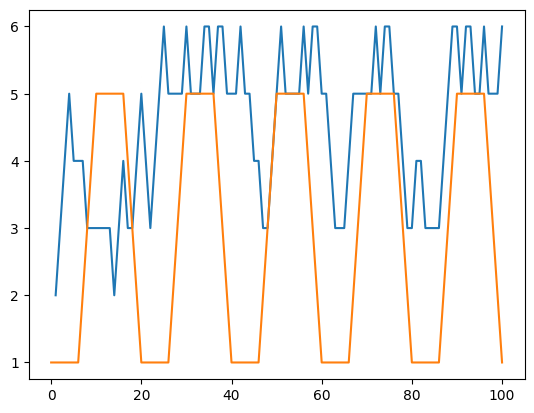

(128, 57) (128,)
128 train done
128 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.4683942171798776


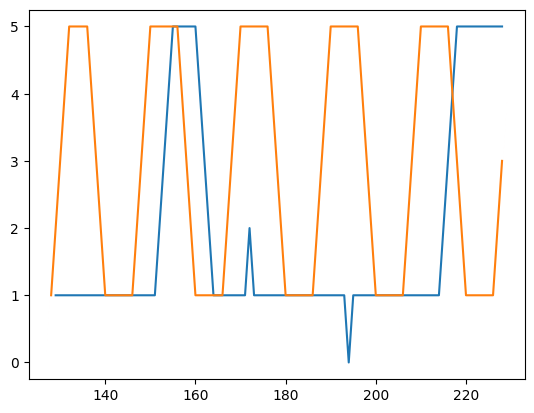

(256, 57) (256,)
256 train done
256 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5] 101
0.0


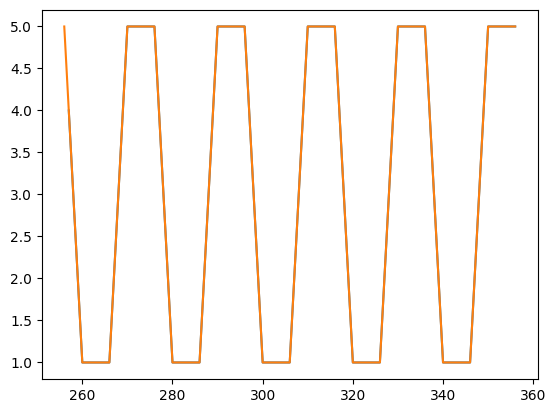

(512, 57) (512,)
512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0


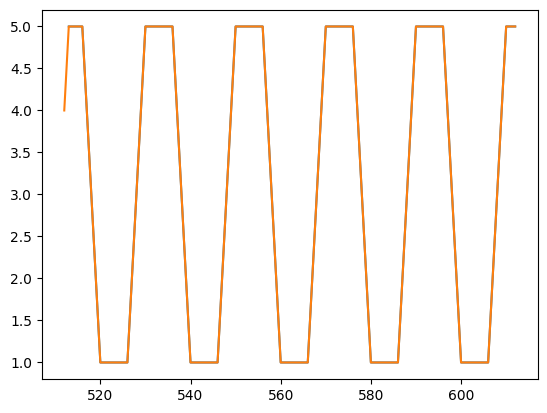

(750, 57) (750,)
750 train done
750 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


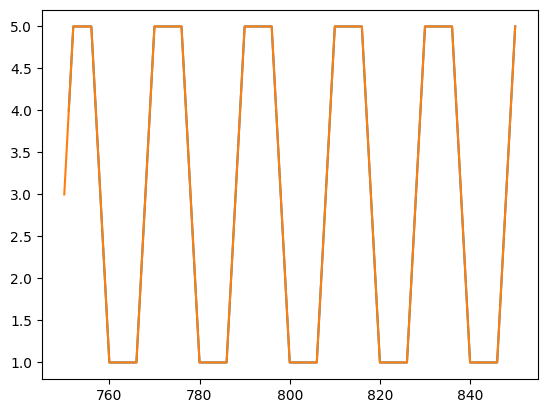

(1024, 57) (1024,)
1024 train done
1024 [np.float64(2.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


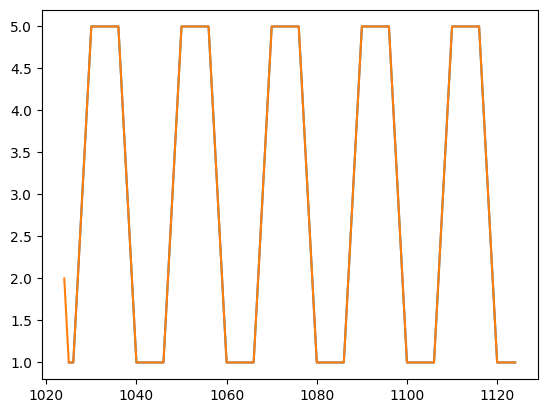

(1250, 57) (1250,)
1250 train done
1250 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


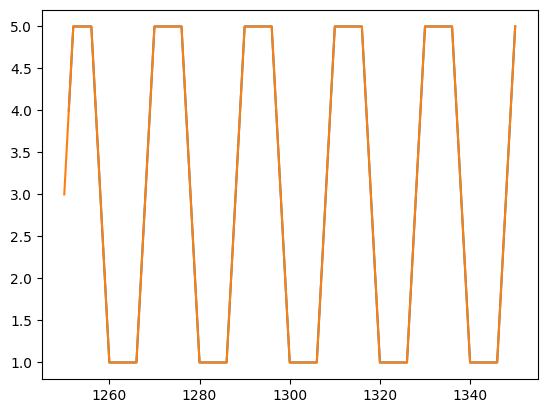

(1500, 57) (1500,)
1500 train done
1500 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


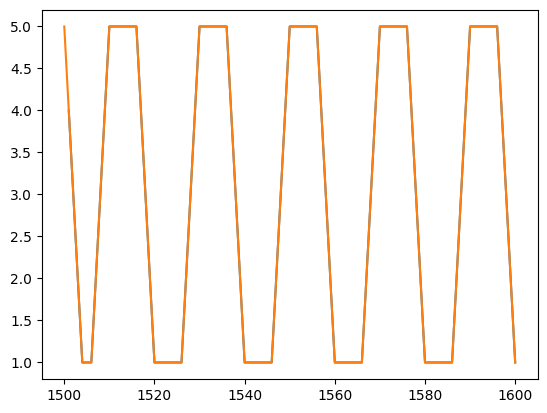

(2048, 57) (2048,)
2048 train done
2048 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


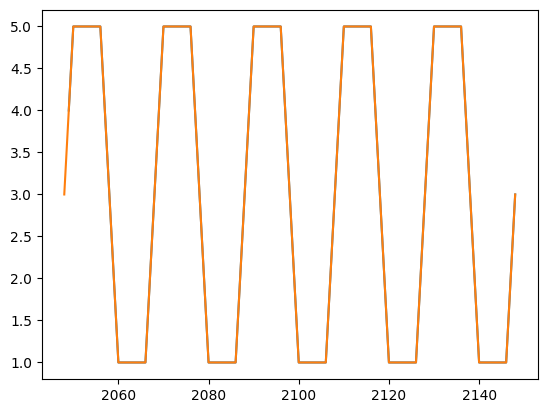

0 train done
0 [np.float64(1.0), 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 3, 4, 4, 3, 2, 2, 2, 3, 4, 4, 3, 2] 101
2.2891747564209566


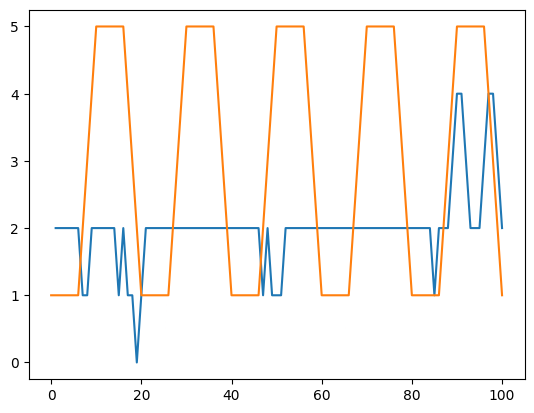

(128, 57) (128,)
128 train done
128 [np.float64(2.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0655543079618541


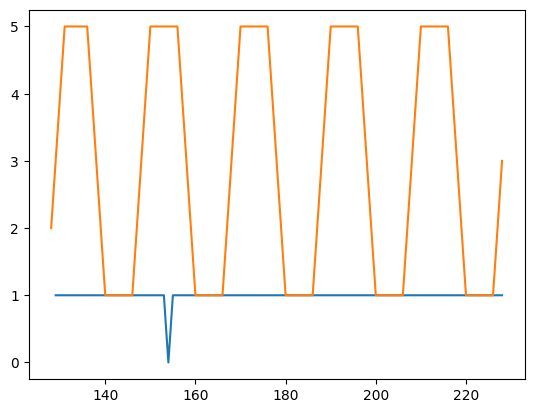

(256, 57) (256,)
256 train done
256 [np.float64(5.0), 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.2836347349263633


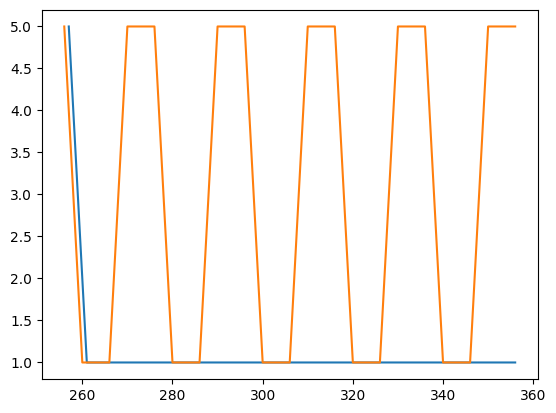

(512, 57) (512,)
512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0


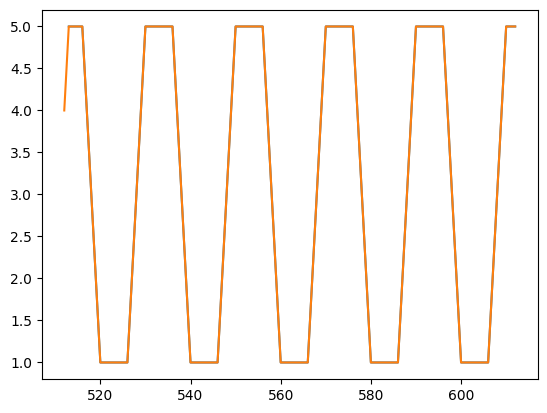

(750, 57) (750,)
750 train done
750 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


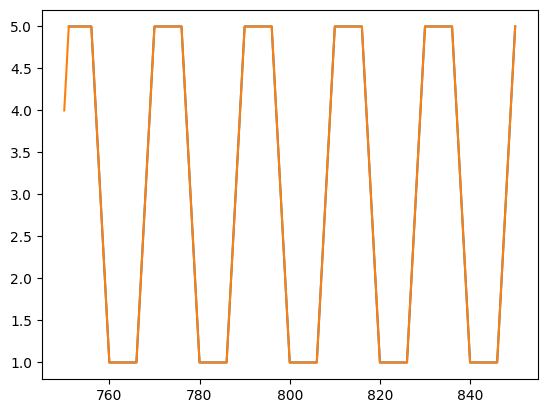

(1024, 57) (1024,)
1024 train done
1024 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


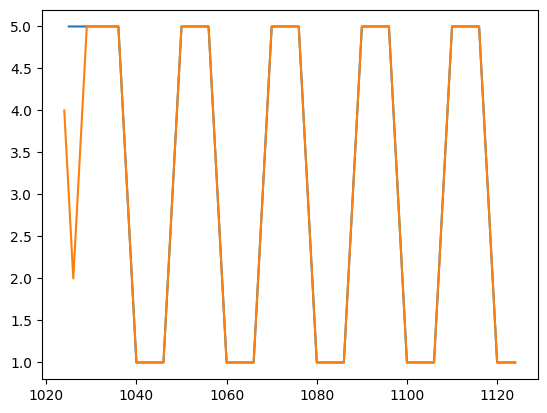

(1250, 57) (1250,)
1250 train done
1250 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


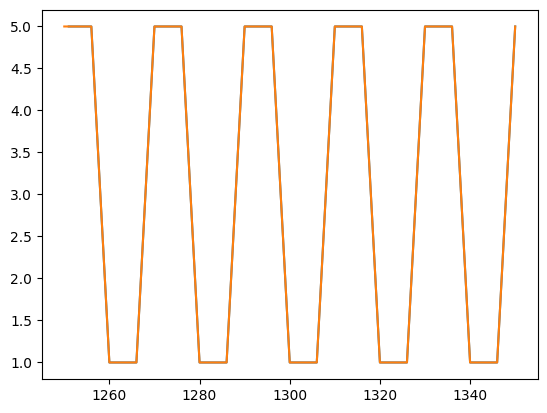

(1500, 57) (1500,)
1500 train done
1500 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


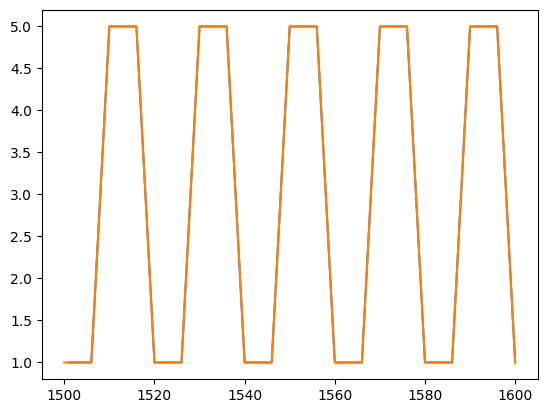

(2048, 57) (2048,)
2048 train done
2048 [np.float64(5.0), 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


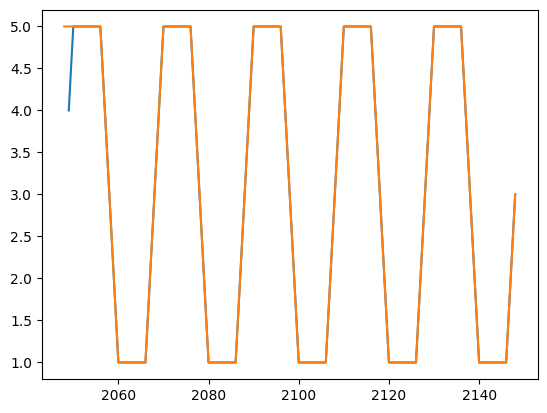

0 train done
0 [np.float64(1.0), 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2] 101
2.2082596510634906


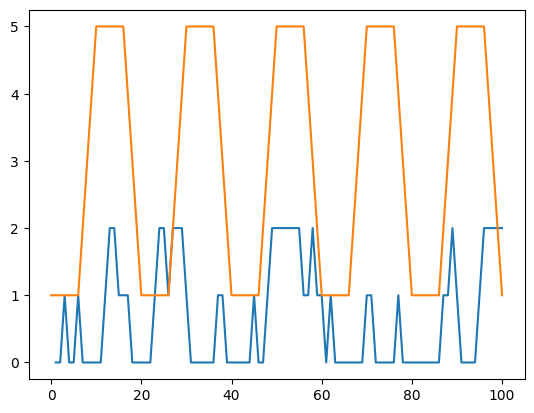

(128, 57) (128,)
128 train done
128 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.1944262409041344


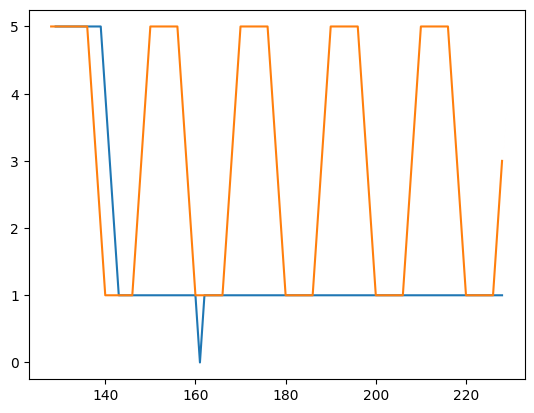

(256, 57) (256,)
256 train done
256 [np.float64(3.0), 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.1491331349263592


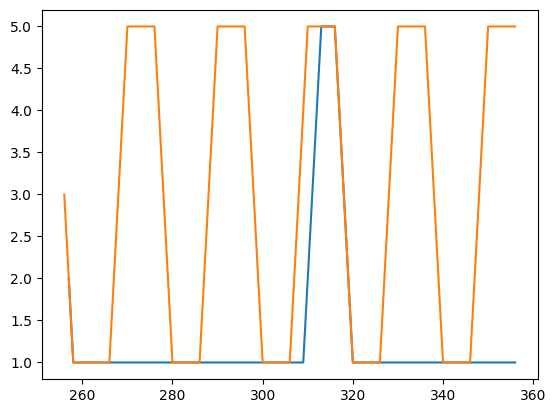

(512, 57) (512,)
512 train done
512 [np.float64(5.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 5, 5, 5, 5, 5] 101
0.708848060234374


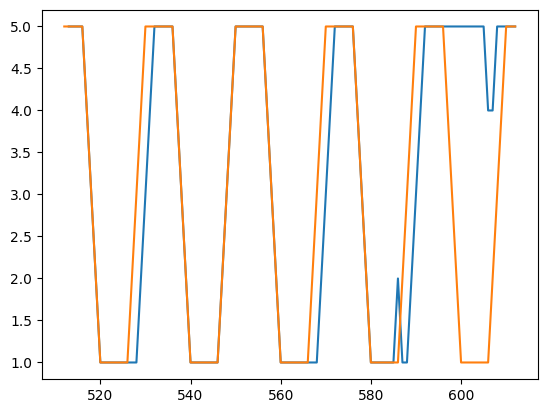

(750, 57) (750,)
750 train done
750 [np.float64(0.0), 1, 2, 3, 4, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


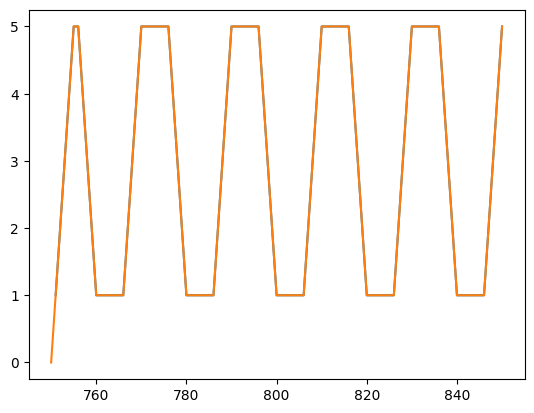

(1024, 57) (1024,)
1024 train done
1024 [np.float64(2.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


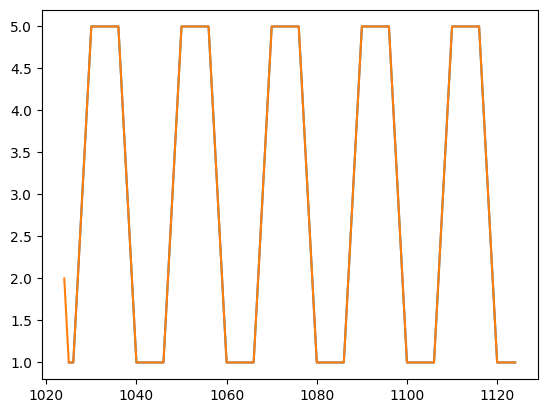

(1250, 57) (1250,)
1250 train done
1250 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


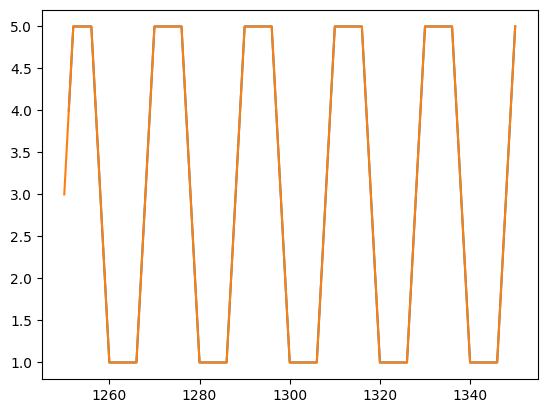

(1500, 57) (1500,)
1500 train done
1500 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


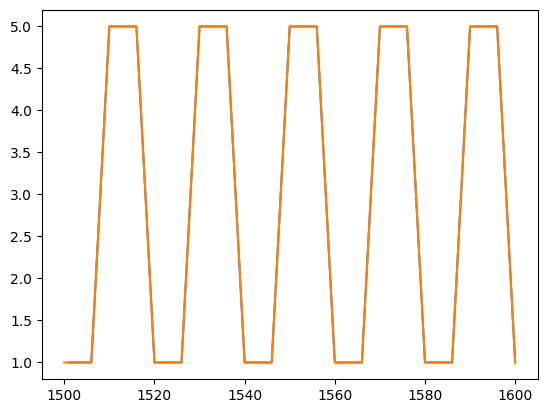

(2048, 57) (2048,)
2048 train done
2048 [np.float64(0.0), 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


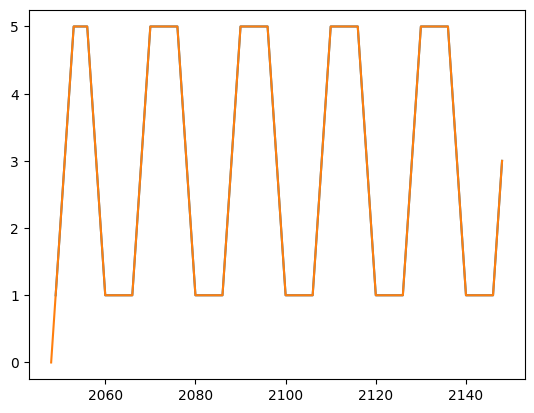

0 train done
0 [np.float64(1.0), 2, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 1, 0, 1, 2, 3, 3, 2, 2, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 2, 2, 2, 3, 3, 3, 2, 3, 2, 2, 2, 3, 3, 3, 3, 2, 1, 2, 3, 3, 2, 2, 2, 1, 0, 1, 2, 2, 3, 3, 3, 3, 3, 2, 2] 101
2.215996606214924


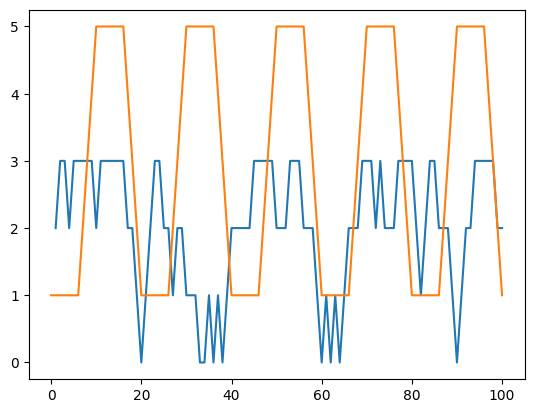

(128, 57) (128,)
128 train done
128 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
1.1513747351943229


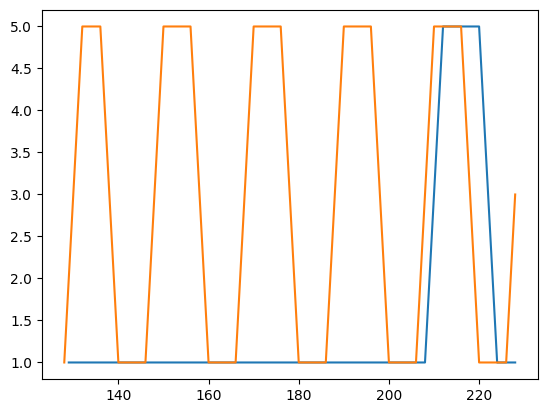

(256, 57) (256,)
256 train done
256 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.23859274891692478


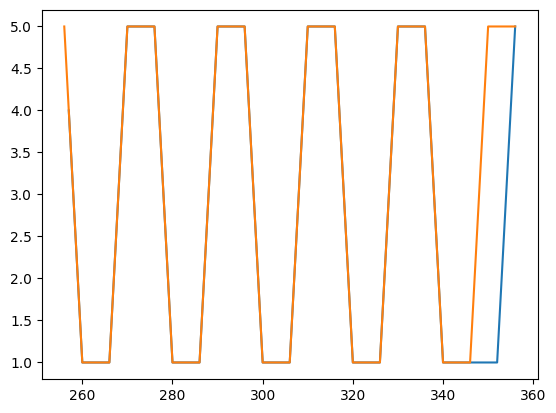

(512, 57) (512,)
512 train done
512 [np.float64(3.0), 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.23751400221939037


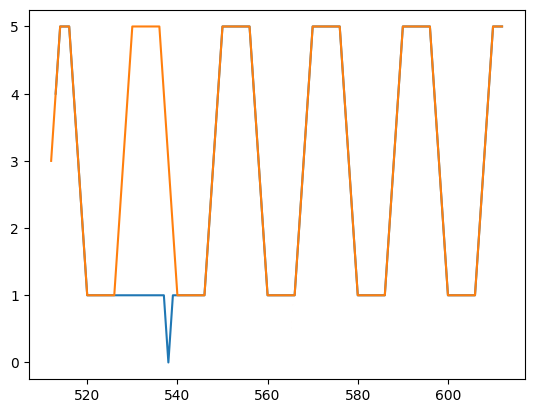

(750, 57) (750,)
750 train done
750 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


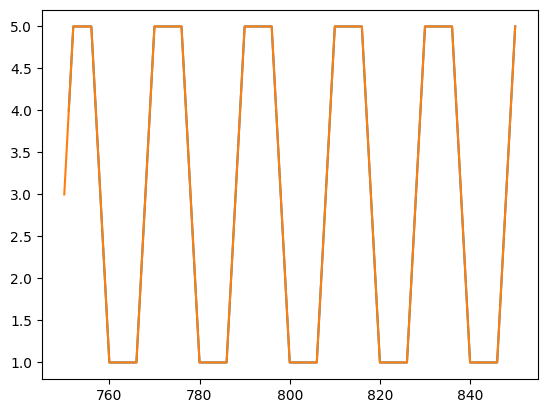

(1024, 57) (1024,)
1024 train done
1024 [np.float64(4.0), 5, 4, 5, 4, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


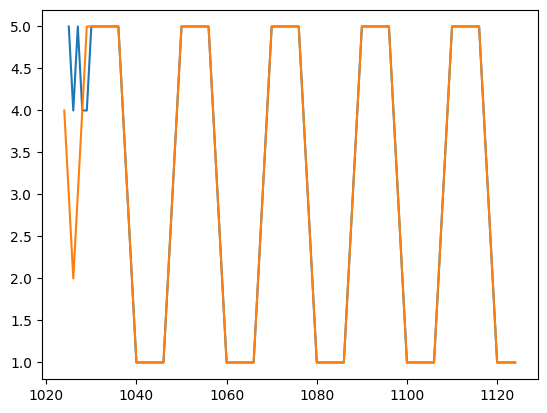

(1250, 57) (1250,)
1250 train done
1250 [np.float64(2.0), 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


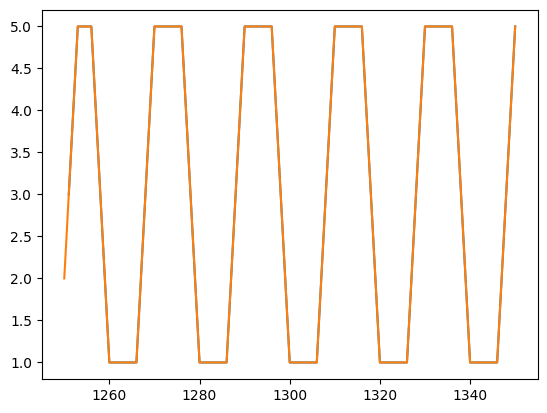

(1500, 57) (1500,)
1500 train done
1500 [np.float64(4.0), 3, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


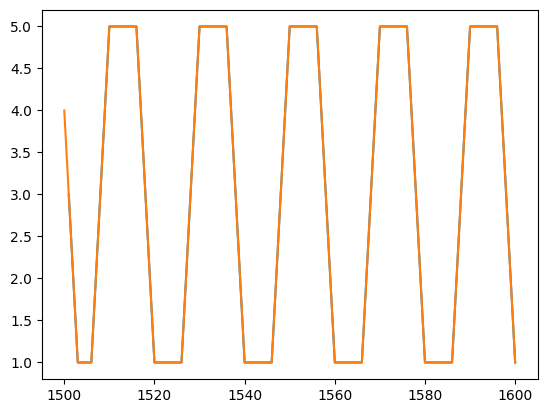

(2048, 57) (2048,)
2048 train done
2048 [np.float64(6.0), 6, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


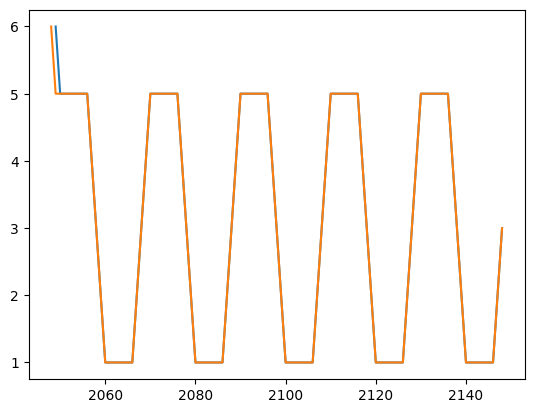

0 train done
0 [np.float64(1.0), 0, 0, 1, 2, 1, 1, 2, 2, 1, 0, 1, 0, 1, 2, 1, 2, 2, 3, 3, 3, 3, 3, 3, 2, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 3, 3, 3, 2, 1, 1, 2, 1, 1, 1, 2, 3, 3, 3, 2, 1, 1, 1, 0, 0, 1, 1, 2, 3, 2, 3, 3, 3, 2, 1, 1, 1, 0, 0, 0, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2] 101
2.1465911833464073


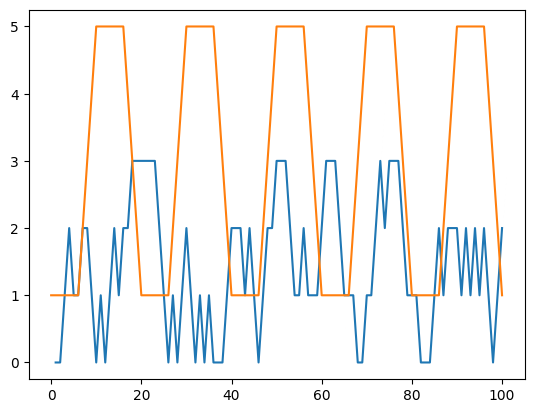

(128, 57) (128,)
128 train done
128 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.020554307961854


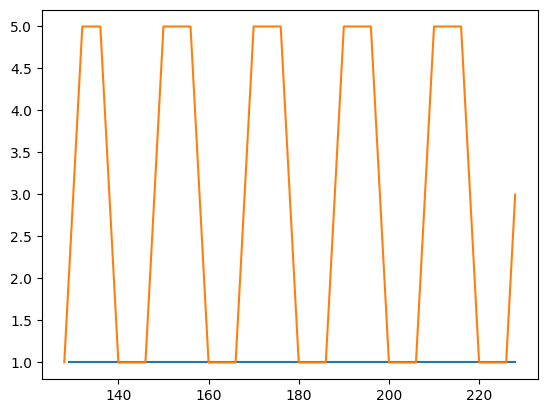

(256, 57) (256,)
256 train done
256 [np.float64(0.0), 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3] 101
0.9945351503239681


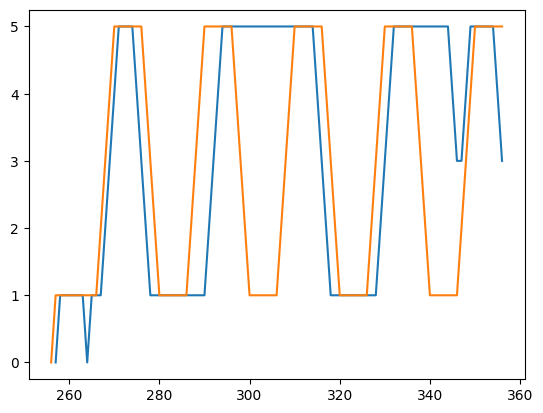

(512, 57) (512,)
512 train done
512 [np.float64(5.0), 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 2, 3, 4] 101
0.41567134046138476


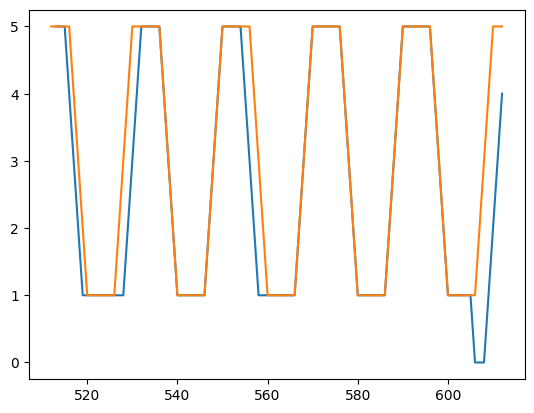

(750, 57) (750,)
750 train done
750 [np.float64(2.0), 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4] 101
0.15774687867803577


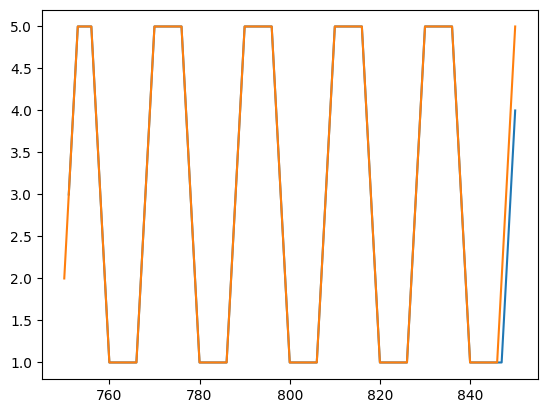

(1024, 57) (1024,)
1024 train done
1024 [np.float64(0.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


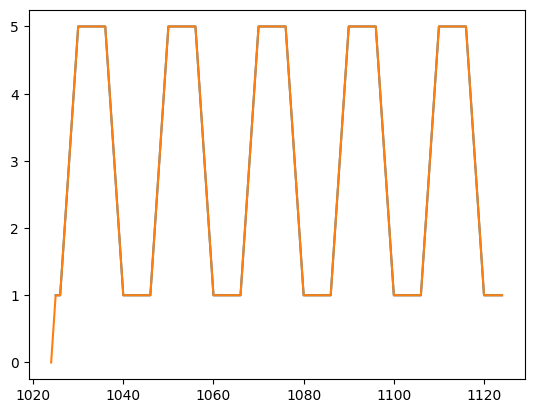

(1250, 57) (1250,)
1250 train done
1250 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


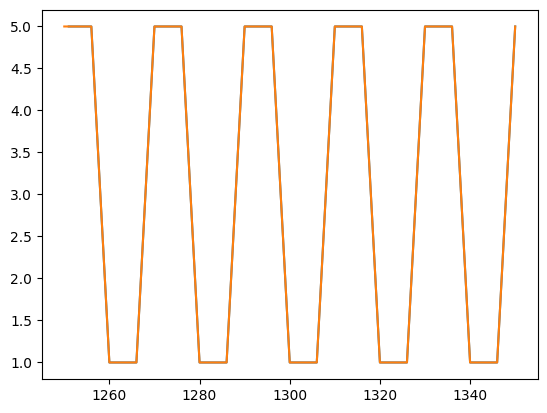

(1500, 57) (1500,)
1500 train done
1500 [np.float64(4.0), 3, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


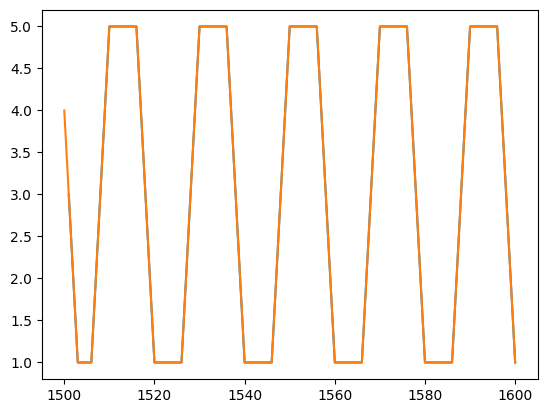

(2048, 57) (2048,)
2048 train done
2048 [np.float64(1.0), 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


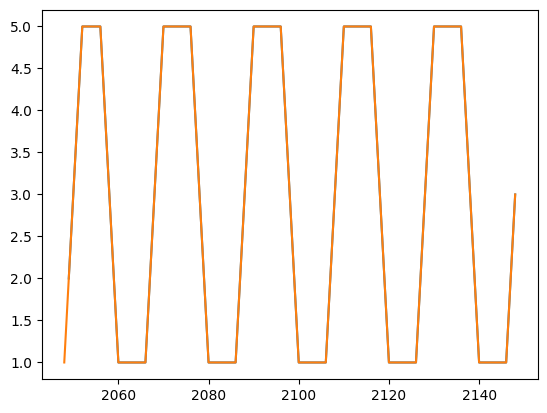

0 train done
0 [np.float64(1.0), 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1] 101
1.9033405441334919


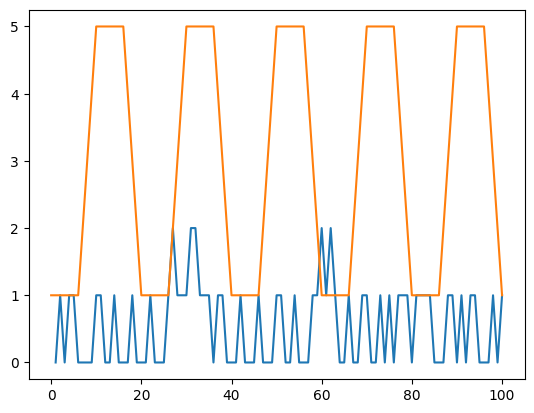

(128, 57) (128,)
128 train done
128 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1892779714209343


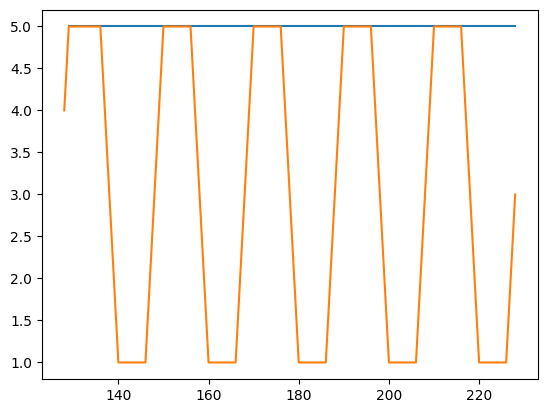

(256, 57) (256,)
256 train done
256 [np.float64(6.0), 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0791053608681012


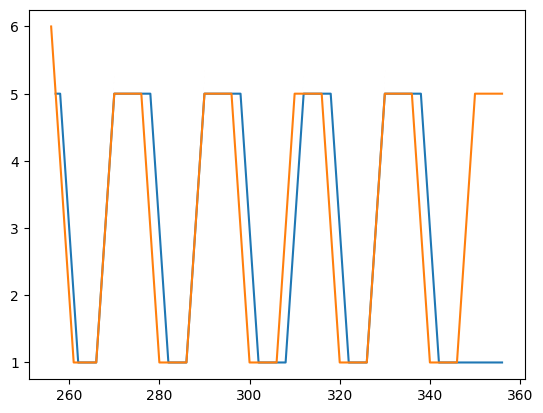

(512, 57) (512,)
512 train done
512 [np.float64(3.0), 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.3977007324257096


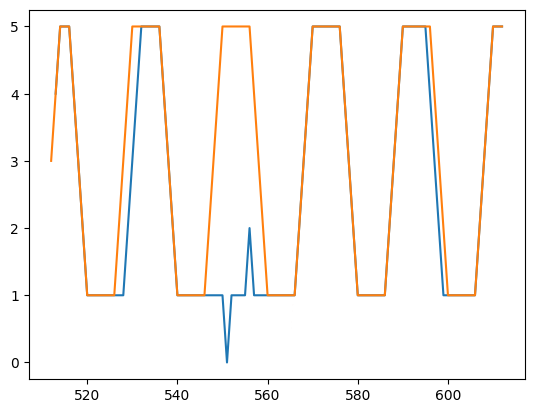

(750, 57) (750,)
750 train done
750 [np.float64(6.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


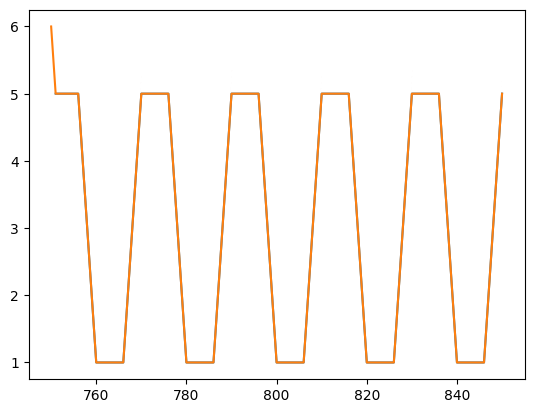

(1024, 57) (1024,)
1024 train done
1024 [np.float64(1.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


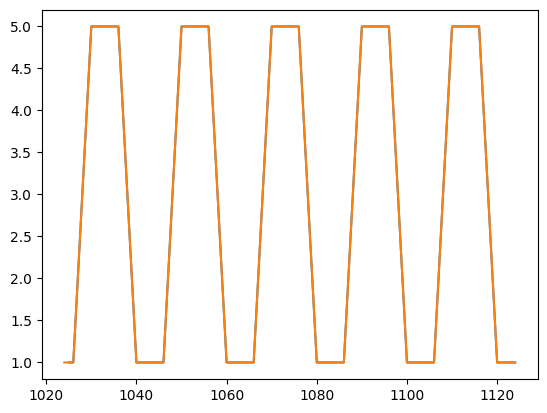

(1250, 57) (1250,)
1250 train done
1250 [np.float64(0.0), 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.011809800000000053


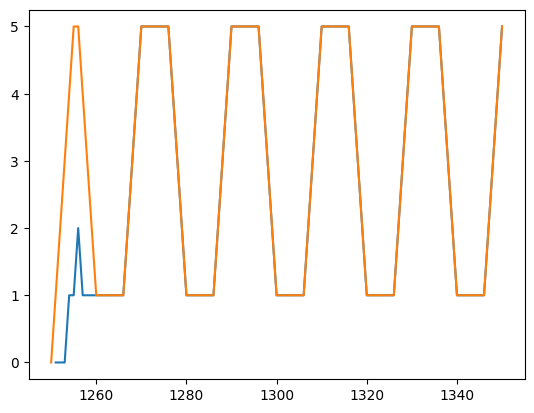

(1500, 57) (1500,)
1500 train done
1500 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


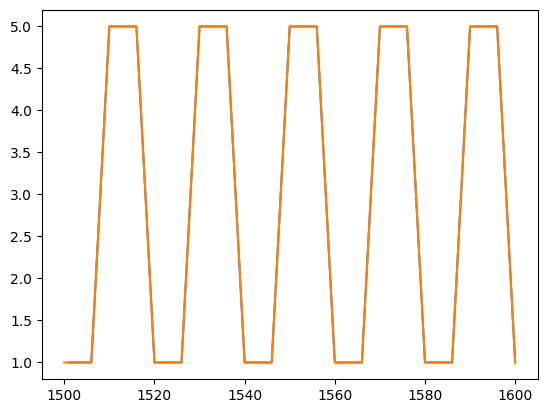

(2048, 57) (2048,)
2048 train done
2048 [np.float64(6.0), 6, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


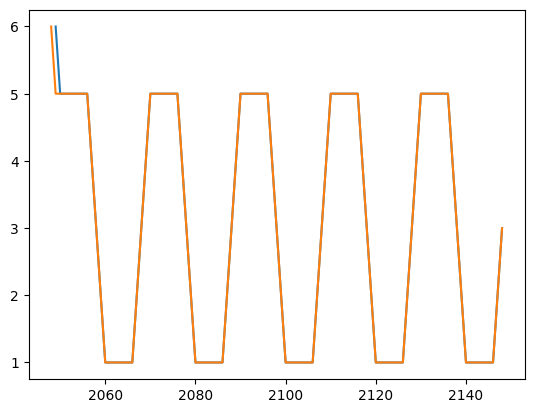

0 train done
0 [np.float64(1.0), 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 3, 2, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 1, 1, 2, 2, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 1, 2, 3, 3, 2, 3, 3, 3, 3, 2, 2, 1, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3] 101
2.233420435767195


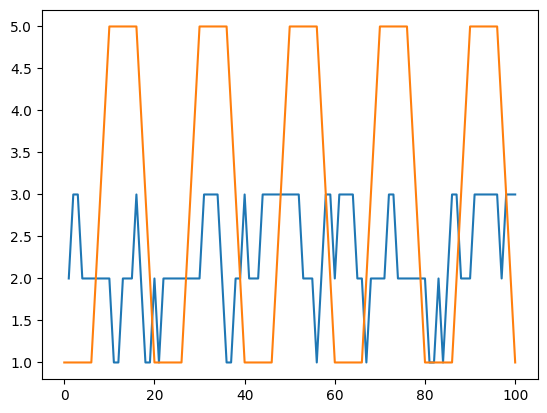

(128, 57) (128,)
128 train done
128 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.115554307961854


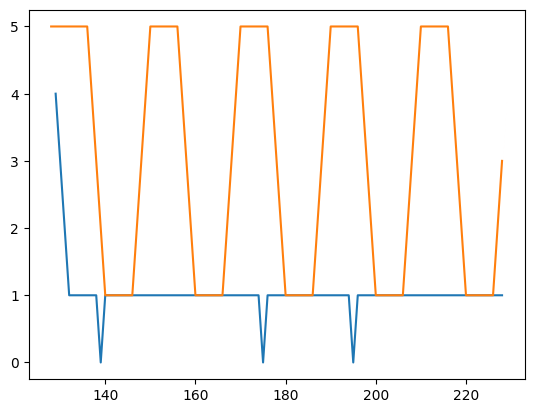

(256, 57) (256,)
256 train done
256 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
0.7211050197302936


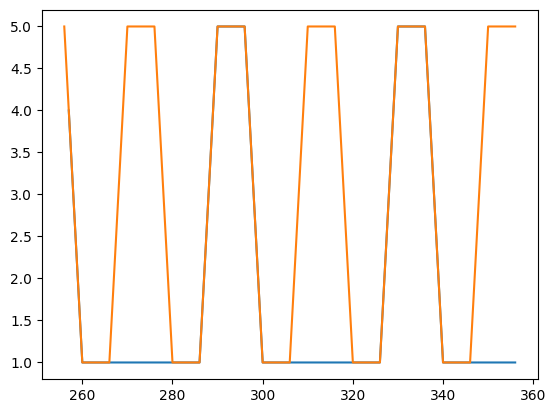

(512, 57) (512,)
512 train done
512 [np.float64(5.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.2877139023186925


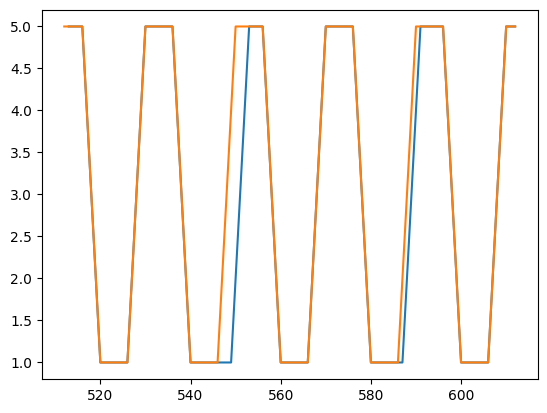

(750, 57) (750,)
750 train done
750 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.19440131167777935


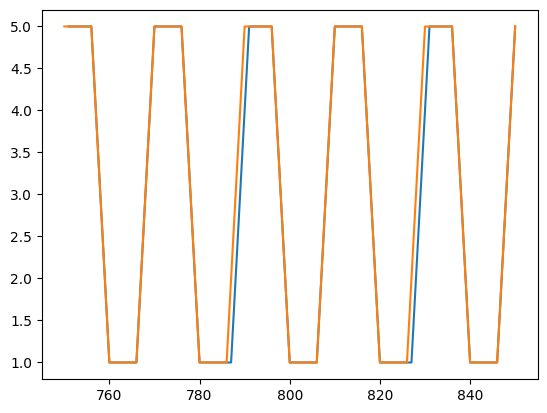

(1024, 57) (1024,)
1024 train done
1024 [np.float64(0.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


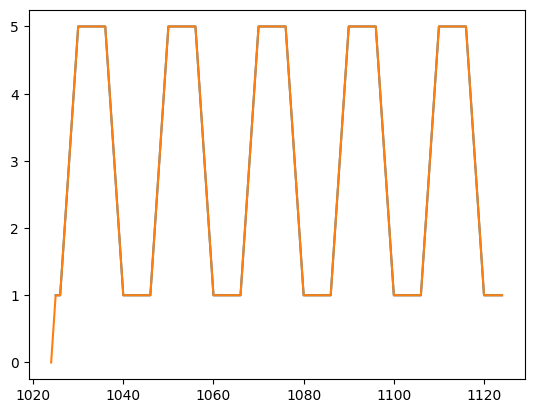

(1250, 57) (1250,)
1250 train done
1250 [np.float64(1.0), 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


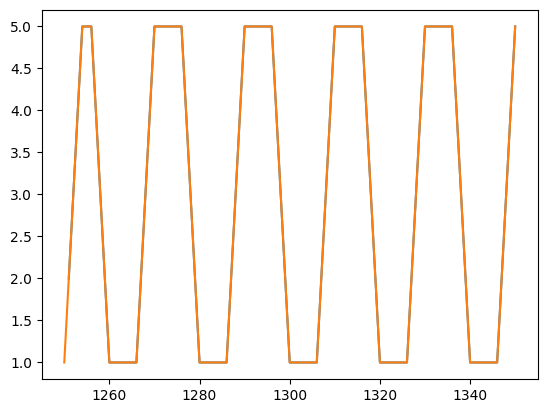

(1500, 57) (1500,)
1500 train done
1500 [np.float64(3.0), 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


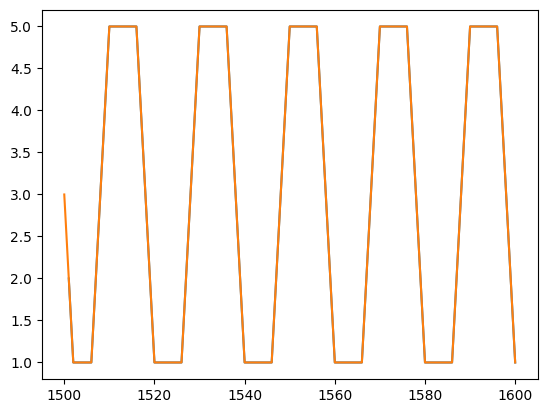

(2048, 57) (2048,)
2048 train done
2048 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


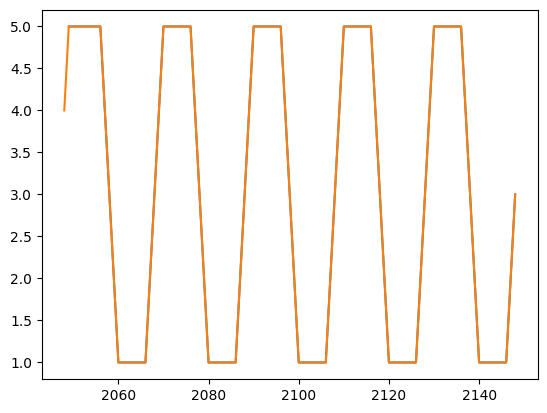

0 train done
0 [np.float64(1.0), 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 0, 1, 1, 2, 3, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1] 101
1.5158264250830005


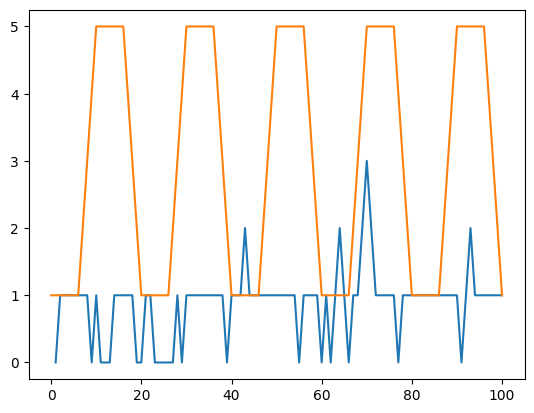

(128, 57) (128,)
128 train done
128 [np.float64(4.0), 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.115554307961854


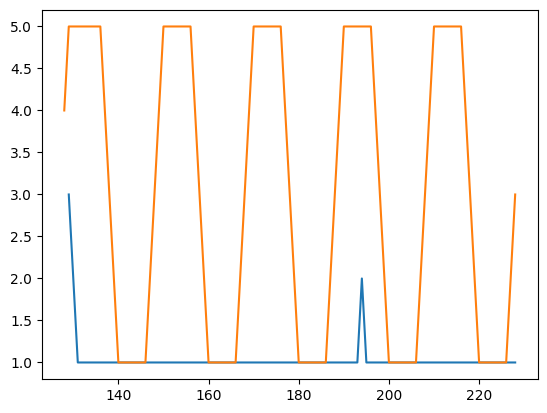

(256, 57) (256,)
256 train done
256 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
1.1170793265109498


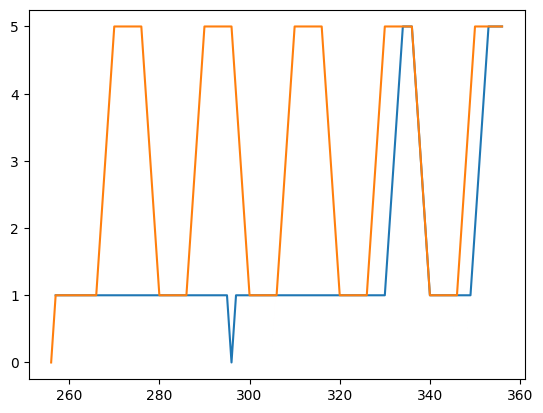

(512, 57) (512,)
512 train done
512 [np.float64(1.0), 2, 3, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.15552102400001616


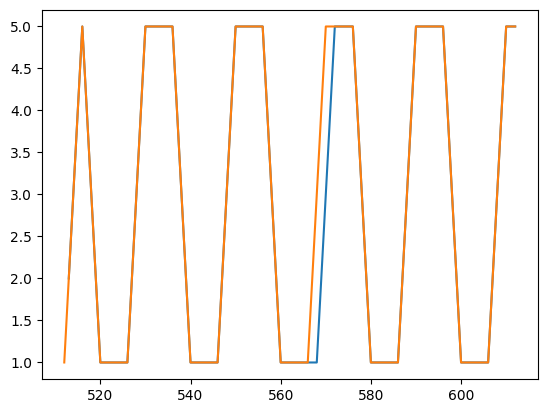

(750, 57) (750,)
750 train done
750 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


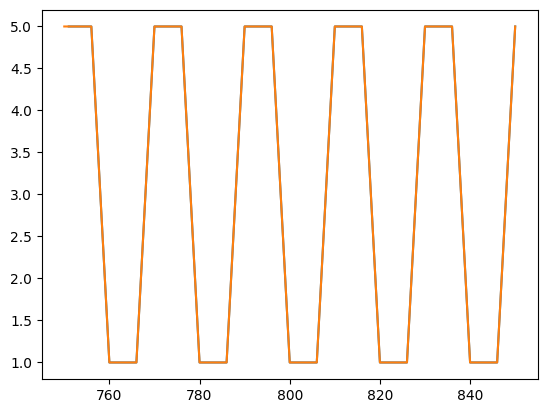

(1024, 57) (1024,)
1024 train done
1024 [np.float64(1.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


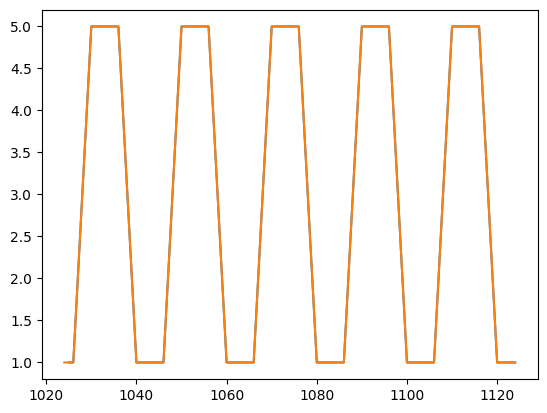

(1250, 57) (1250,)
1250 train done
1250 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


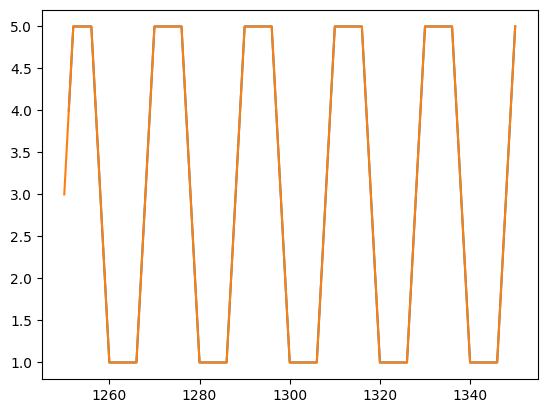

(1500, 57) (1500,)
1500 train done
1500 [np.float64(2.0), 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


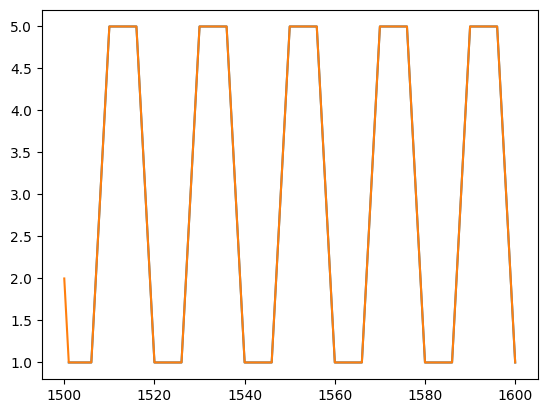

(2048, 57) (2048,)
2048 train done
2048 [np.float64(5.0), 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


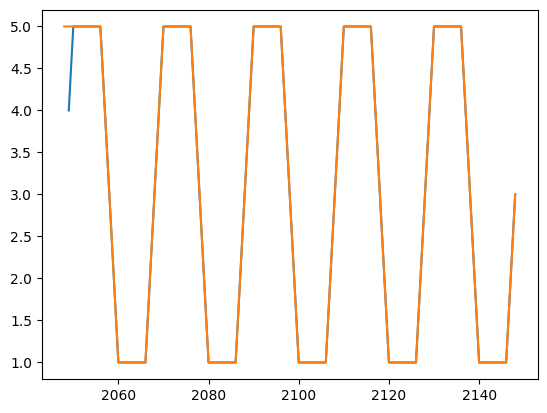

0 train done
0 [np.float64(1.0), 2, 3, 4, 5, 4, 3, 2, 2, 2, 2, 2, 3, 3, 4, 3, 3, 4, 5, 6, 5, 4, 4, 4, 5, 4, 5, 4, 3, 2, 3, 3, 4, 4, 4, 3, 2, 3, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 3, 2, 3, 2, 2, 3, 4, 4, 3, 3, 3, 3, 3, 4, 5, 4, 5, 4, 3, 2, 1, 2, 3, 4, 4, 5, 5, 5, 5, 4, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 1, 2, 2, 3, 4, 5, 5, 6, 6] 101
2.3500598608110805


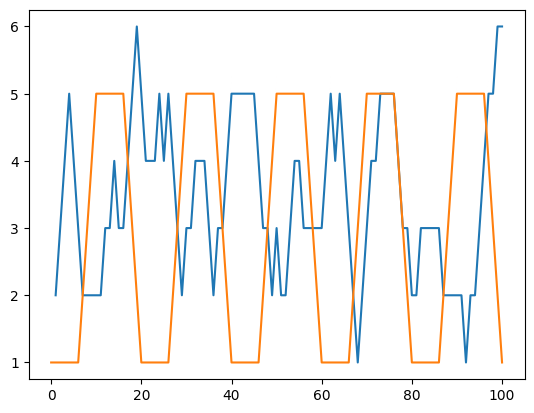

(128, 57) (128,)
128 train done
128 [np.float64(2.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0655543079618541


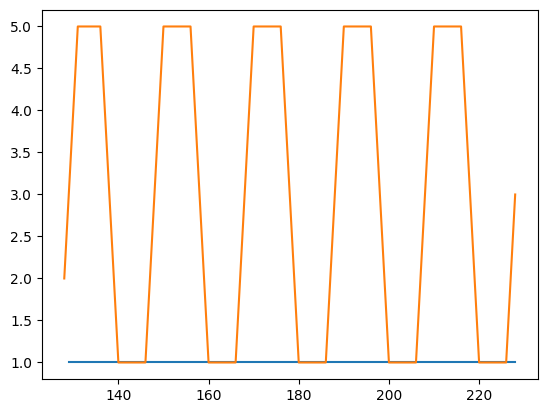

(256, 57) (256,)
256 train done
256 [np.float64(3.0), 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.1961347349263634


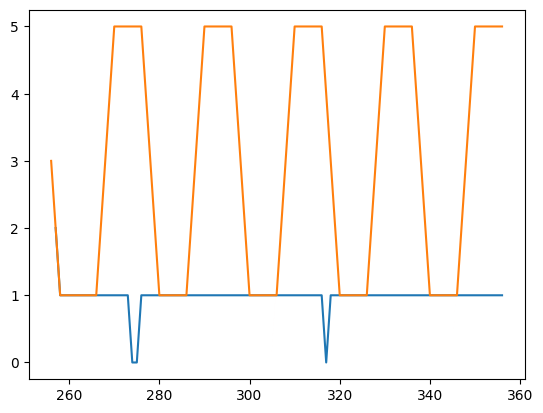

(512, 57) (512,)
512 train done
512 [np.float64(5.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0


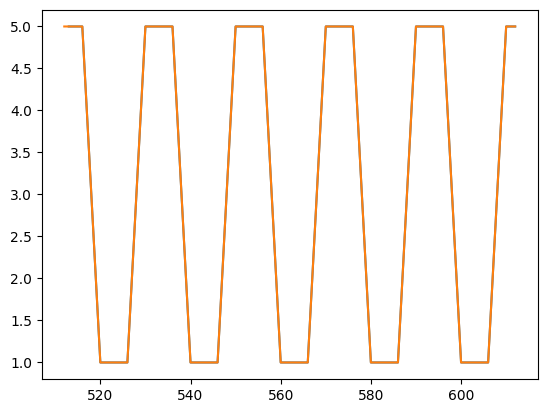

(750, 57) (750,)
750 train done
750 [np.float64(2.0), 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


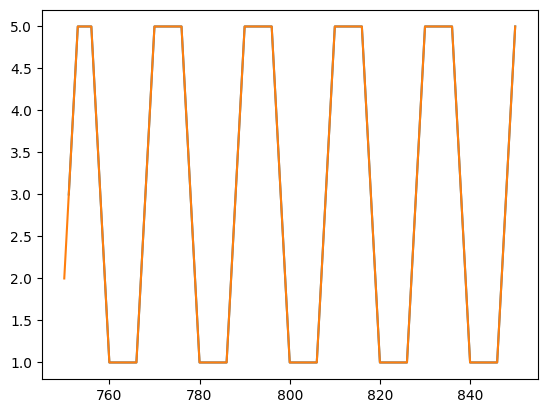

(1024, 57) (1024,)
1024 train done
1024 [np.float64(6.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


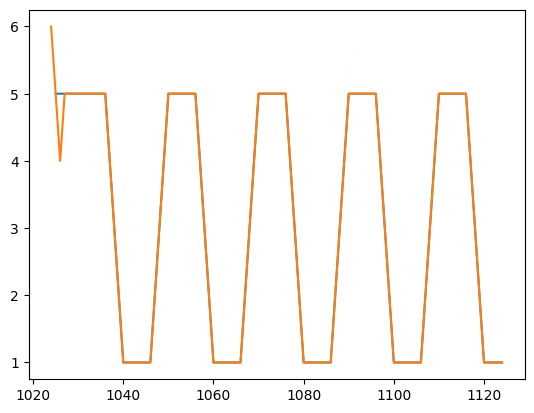

(1250, 57) (1250,)
1250 train done
1250 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


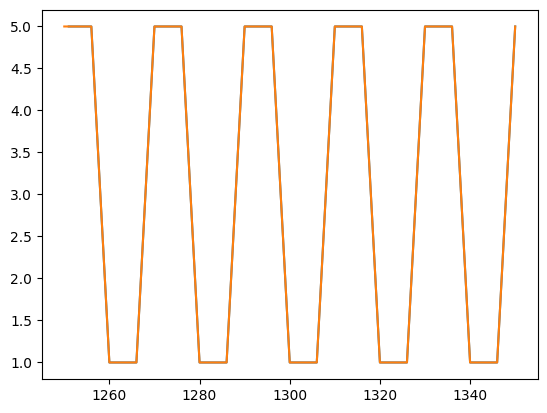

(1500, 57) (1500,)
1500 train done
1500 [np.float64(6.0), 5, 4, 3, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


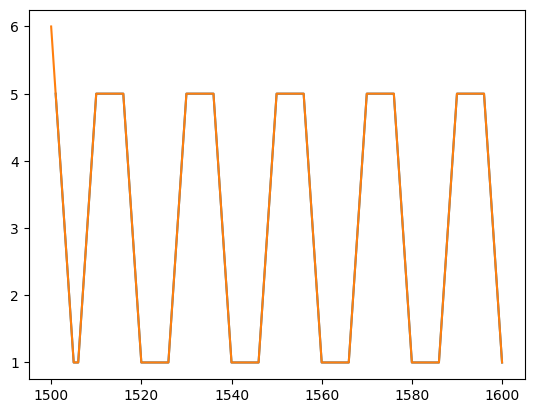

(2048, 57) (2048,)
2048 train done
2048 [np.float64(0.0), 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


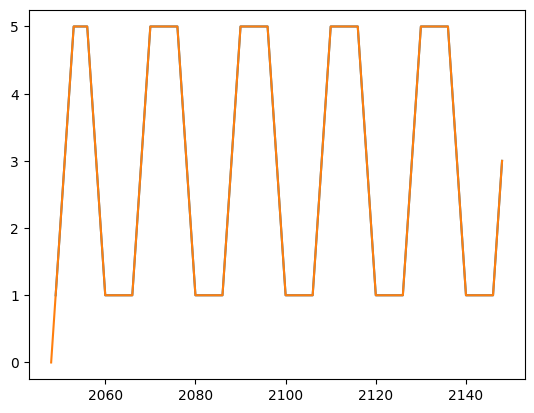

0 train done
0 [np.float64(1.0), 2, 2, 2, 1, 0, 1, 2, 3, 2, 1, 0, 1, 1, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 3, 2, 1, 0, 1, 1, 2, 1, 1, 1, 2, 3, 3, 2, 1, 0, 1, 1, 2, 3, 4, 4, 4, 3, 2, 1, 0, 1, 1, 1, 2, 3, 3, 3, 3, 3, 2, 3, 4, 4, 4, 3, 2, 1, 2, 1, 1, 2, 3, 3, 3, 4, 4, 3, 2, 3, 4, 3, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1] 101
1.7690580526412354


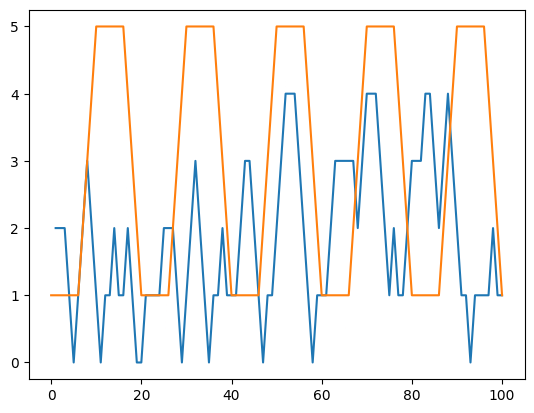

(128, 57) (128,)
128 train done
128 [np.float64(3.0), 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.115554307961854


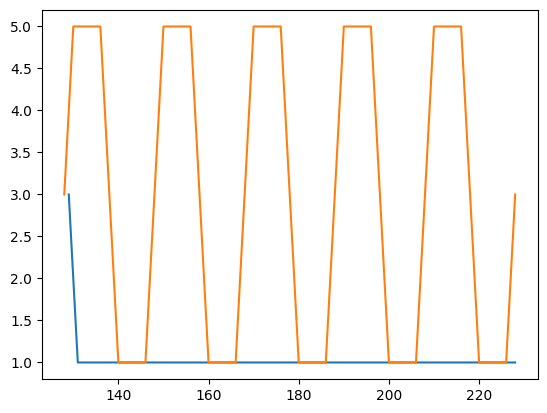

(256, 57) (256,)
256 train done
256 [np.float64(0.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5] 101
0.7125309347193146


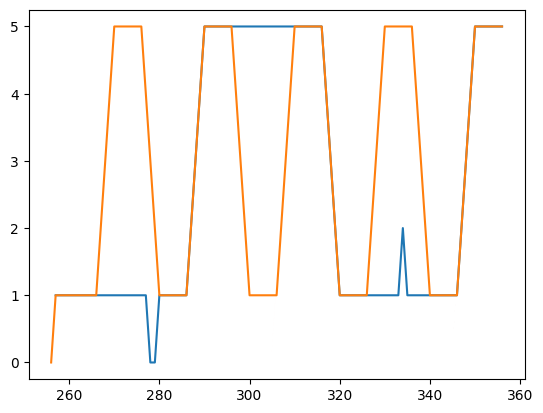

(512, 57) (512,)
512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
0.19909135183769053


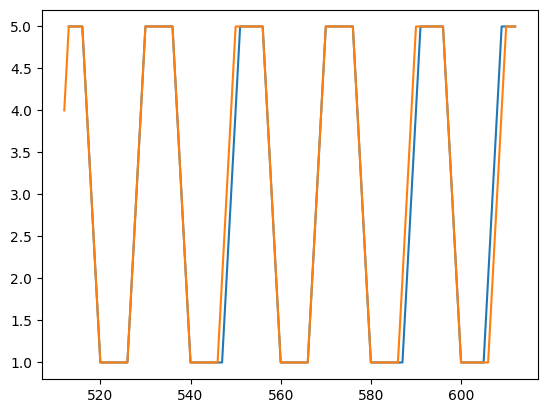

(750, 57) (750,)
750 train done
750 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


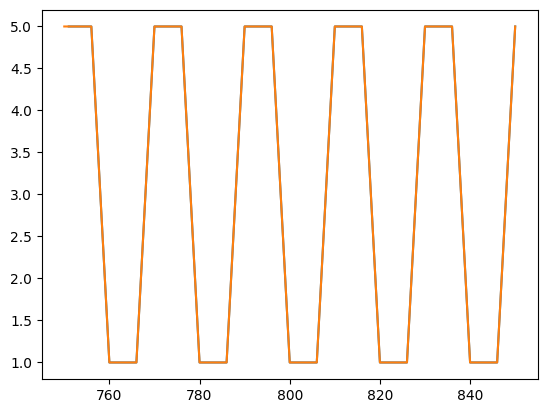

(1024, 57) (1024,)
1024 train done
1024 [np.float64(0.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.00466559777526868


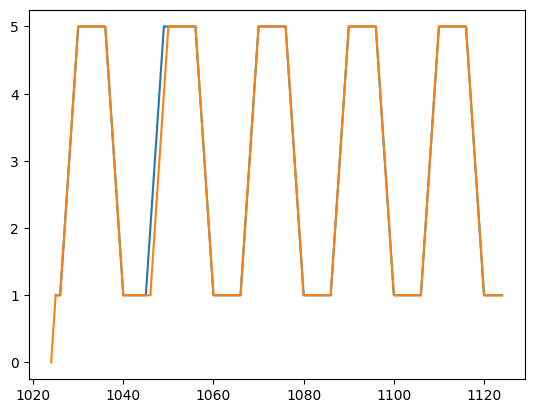

(1250, 57) (1250,)
1250 train done
1250 [np.float64(6.0), 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


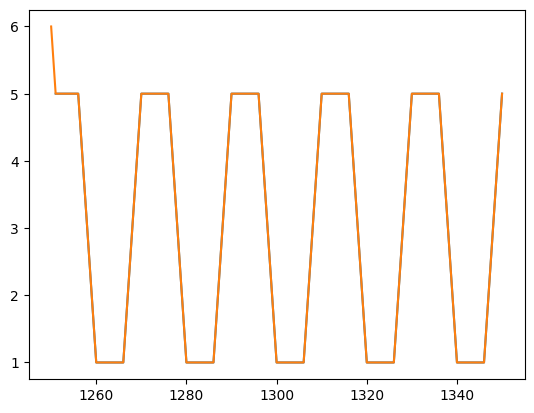

(1500, 57) (1500,)
1500 train done
1500 [np.float64(2.0), 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


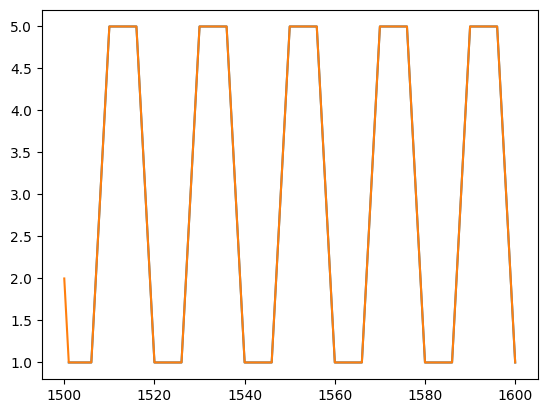

(2048, 57) (2048,)
2048 train done
2048 [np.float64(2.0), 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


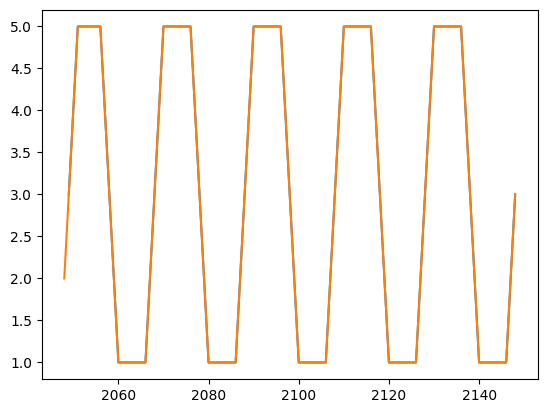

In [5]:
gamma = 0.5
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
Ts = [0,128, 256,512]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
for rep in range(10):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
                    # rf = RandomForestRegressor(n_estimators=1000)
            # rf = ObliqueRandomForestRegressor(n_estimators=1000)
            
            if T ==0:
                n_samples = 50
                X_train = new_state_oh[:n_samples, :]
                y_train = np.random.permutation(irewards[:n_samples])
                rf = xgb.XGBRegressor(objective="reg:squarederror",
                    tree_method = "exact",
                    n_jobs = -1,
                    learning_rate = 0.05,
                    max_depth = 10,
                    subsample=1,
                    colsample_bytree=0.8, 
                    n_estimators = 2000,
                    eval_metric = "rmse")
                rf.fit(X_train, y_train)
            else:
                X_train = new_state_oh[:T,:]
                Y_train = irewards[:T]

                print(X_train.shape,Y_train.shape)
                rf = xgb.XGBRegressor(objective="reg:squarederror",
                    tree_method = "exact",
                    n_jobs = -1,
                    learning_rate = 0.05,
                    max_depth = 10,
                    subsample=1,
                    colsample_bytree=0.8, 
                    n_estimators = 2000,
                    eval_metric = "rmse")
                rf.fit(X_train, Y_train)
            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/Permute_RF_oh_w_time0_2048_lookahead{t_prime}_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )
